In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
from sklearn.preprocessing import MinMaxScaler

def crear_dataset_supervisado(serie, window_size):
    """
    Convierte una serie de tiempo 1D en un dataset supervisado 2D.
    Toma 'window_size' rezagos (X) para predecir el siguiente valor (y).
    """
    X, y = [], []
    for i in range(len(serie) - window_size):
        X.append(serie[i:(i + window_size)])
        y.append(serie[i + window_size])
    return np.array(X), np.array(y)

# =====================================================================
# BLOQUE 1: CARGA, NORMALIZACIÓN GLOBAL Y PARTICIÓN DE DATOS
# =====================================================================

# --- A. Parámetros Configurables por el Usuario ---
n_train = 234             # Tamaño estricto del conjunto de entrenamiento
window_size = 12          # Rezagos para el pronóstico (12 meses de entrada)

print("Seleccione los archivos CSV (ej. MATAMOROS_mensual_curated_train_val.csv...).")
print("IMPORTANTE: Estos archivos SOLO deben contener Entrenamiento y Validación.")
uploaded = files.upload()

archivos_cargados = list(uploaded.keys())
print(f"\nSe han detectado {len(archivos_cargados)} archivos. Iniciando partición DLF...\n")

# Diccionario maestro para almacenar las series
datos_dlf = {}

for filename in archivos_cargados:
    # Extraemos solo la primera palabra del archivo (ej. MATAMOROS)
    city = filename.split('_')[0]

    # 1. Lectura del archivo en formato ancho (AÑO, ENE, FEB... DIC)
    df = pd.read_csv(filename, encoding='latin1')

    # 2. Transformación a serie 1D cronológica
    series_raw = df.iloc[:, 1:].values.flatten()
    series_raw = series_raw[~np.isnan(series_raw)]

    # 3. NORMALIZACIÓN GLOBAL DESDE LA RAÍZ
    # Se normaliza toda la serie junta antes de cualquier partición
    scaler = MinMaxScaler(feature_range=(0, 1))
    series_scaled = scaler.fit_transform(series_raw.reshape(-1, 1)).flatten()

    # 4. Cálculo dinámico de partición de Validación
    n_val = len(series_scaled) - n_train

    # 5. Partición estricta cronológica sobre la serie YA NORMALIZADA
    train_scaled = series_scaled[:n_train]
    val_scaled   = series_scaled[n_train:n_train + n_val]
    history_scaled = np.concatenate((train_scaled, val_scaled))

    # 6. Extensión para mantener la longitud de la ventana
    val_extendido_scaled = series_scaled[n_train - window_size : n_train + n_val]

    # 7. Transformación a aprendizaje supervisado
    X_train, y_train = crear_dataset_supervisado(train_scaled, window_size)
    X_val, y_val     = crear_dataset_supervisado(val_extendido_scaled, window_size)

    # 8. Almacenamiento estructurado
    datos_dlf[city] = {
        'scaler': scaler,       # Se guarda para hacer el inverse_transform al final
        'raw_full': series_raw, # Serie original por si se necesita graficar
        'scaled': {
            'train': train_scaled,
            'val': val_scaled,
            'history': history_scaled
        },
        'supervised': {
            'X_train': X_train, 'y_train': y_train,
            'X_val': X_val,     'y_val': y_val
        }
    }

    print(f"[{city}] Extraídos {len(series_raw)} datos -> Entrenando con: {len(y_train)} targets | Validando con: {len(y_val)} targets")

print("\nEstructura de datos lista. Diccionario 'datos_dlf' poblado y normalizado exitosamente.")

Seleccione los archivos CSV (ej. MATAMOROS_mensual_curated_train_val.csv...).
IMPORTANTE: Estos archivos SOLO deben contener Entrenamiento y Validación.


Saving HOUSTON_trainval.csv to HOUSTON_trainval.csv
Saving MATAMOROS_trainval.csv to MATAMOROS_trainval.csv
Saving MIAMI_trainval.csv to MIAMI_trainval.csv
Saving TAMPICO_trainval.csv to TAMPICO_trainval.csv

Se han detectado 4 archivos. Iniciando partición DLF...

[HOUSTON] Extraídos 302 datos -> Entrenando con: 222 targets | Validando con: 68 targets
[MATAMOROS] Extraídos 302 datos -> Entrenando con: 222 targets | Validando con: 68 targets
[MIAMI] Extraídos 302 datos -> Entrenando con: 222 targets | Validando con: 68 targets
[TAMPICO] Extraídos 302 datos -> Entrenando con: 222 targets | Validando con: 68 targets

Estructura de datos lista. Diccionario 'datos_dlf' poblado y normalizado exitosamente.


--- Aplicando Filtros de Descomposición (SMA3, SMA6, Fk) ---
Nota: Medias móviles calculadas con 'center=True' para evitar desfase de fase.
Nota: Se calculan sobre la serie YA NORMALIZADA (Train + Val).

[ÉXITO] Filtros y residuales normalizados calculados y almacenados para las 4 ciudades.


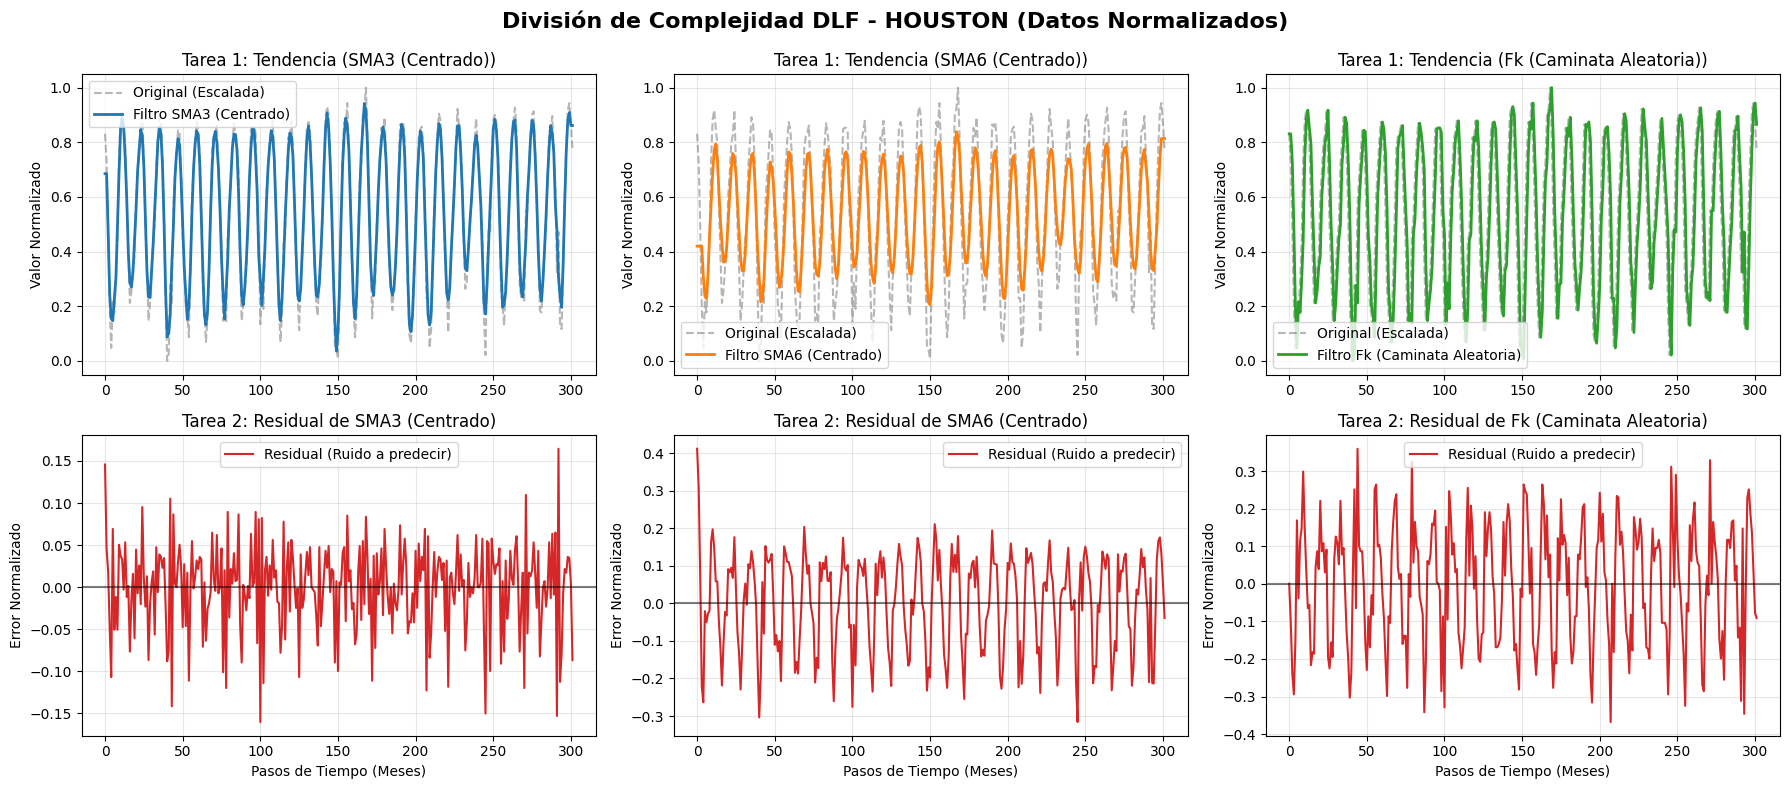

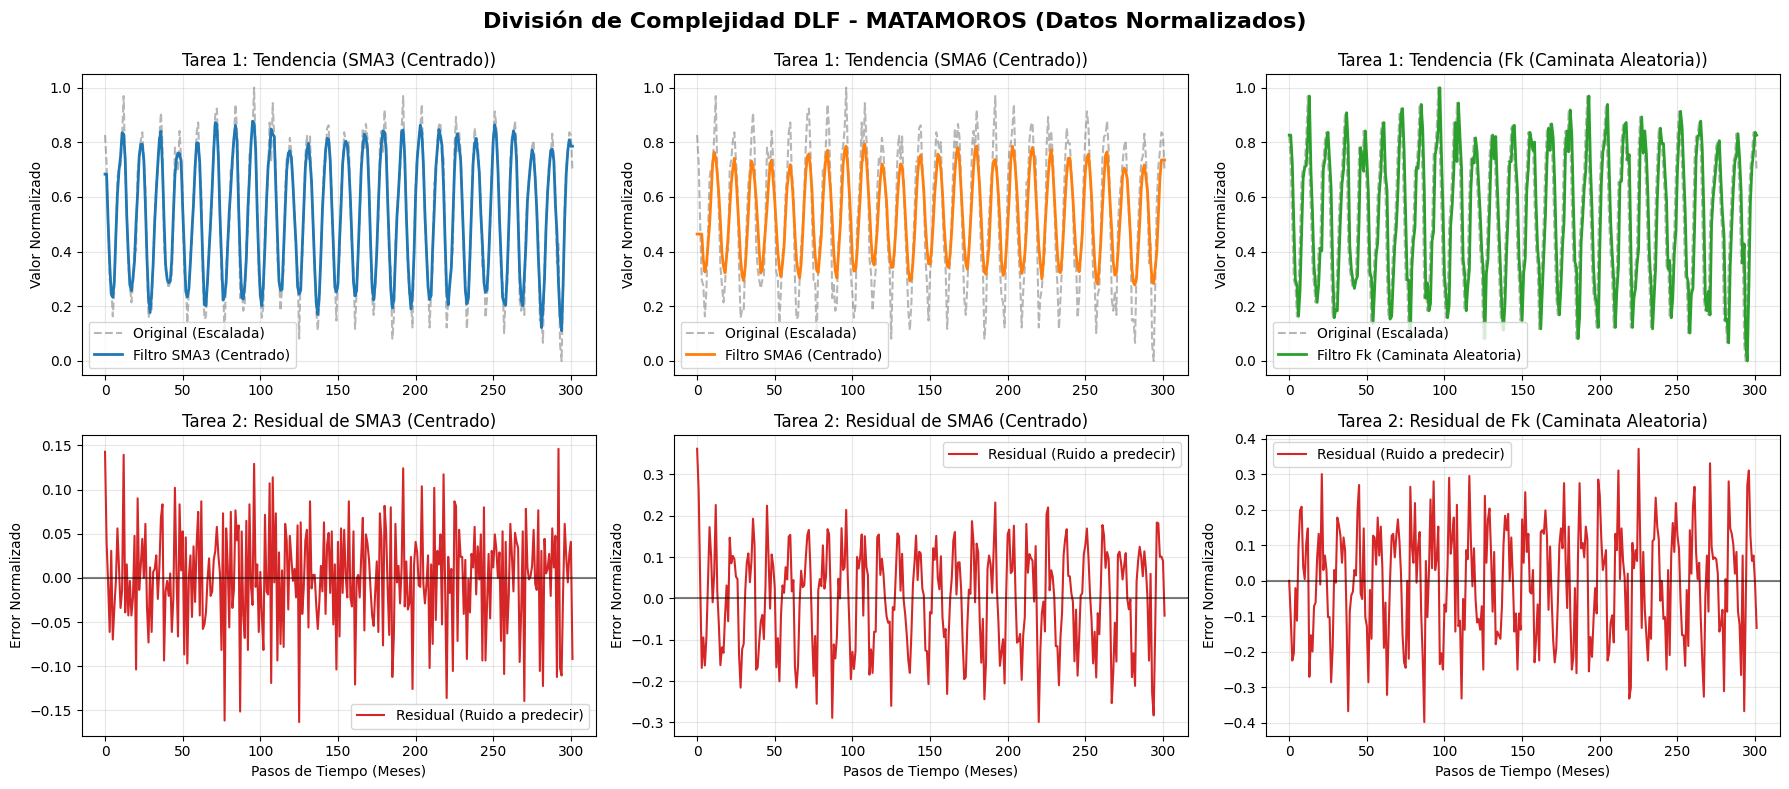

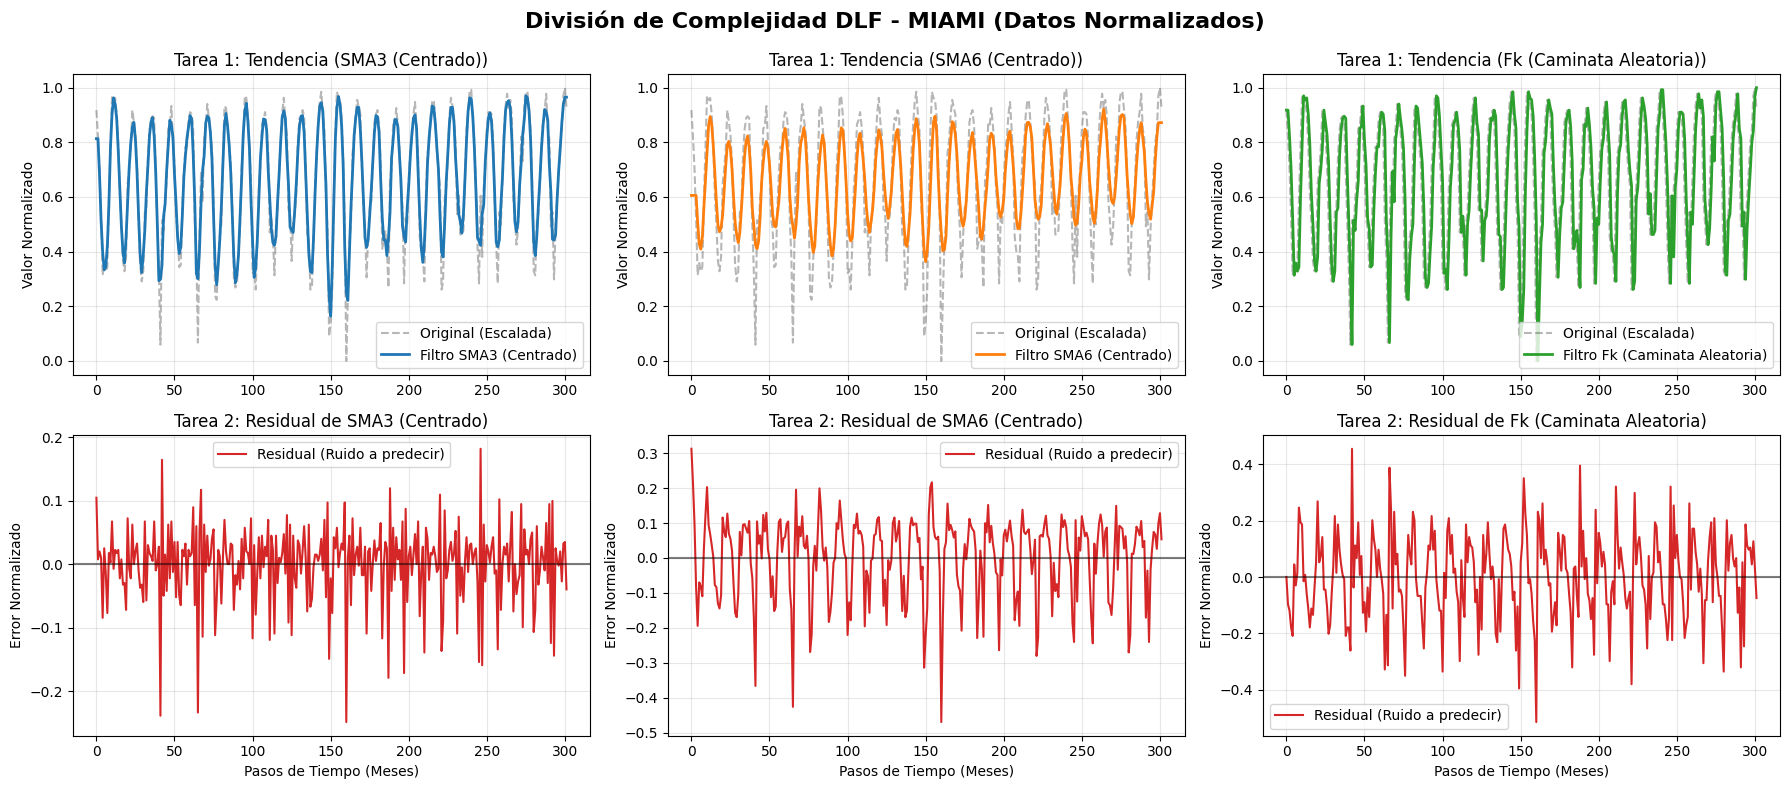

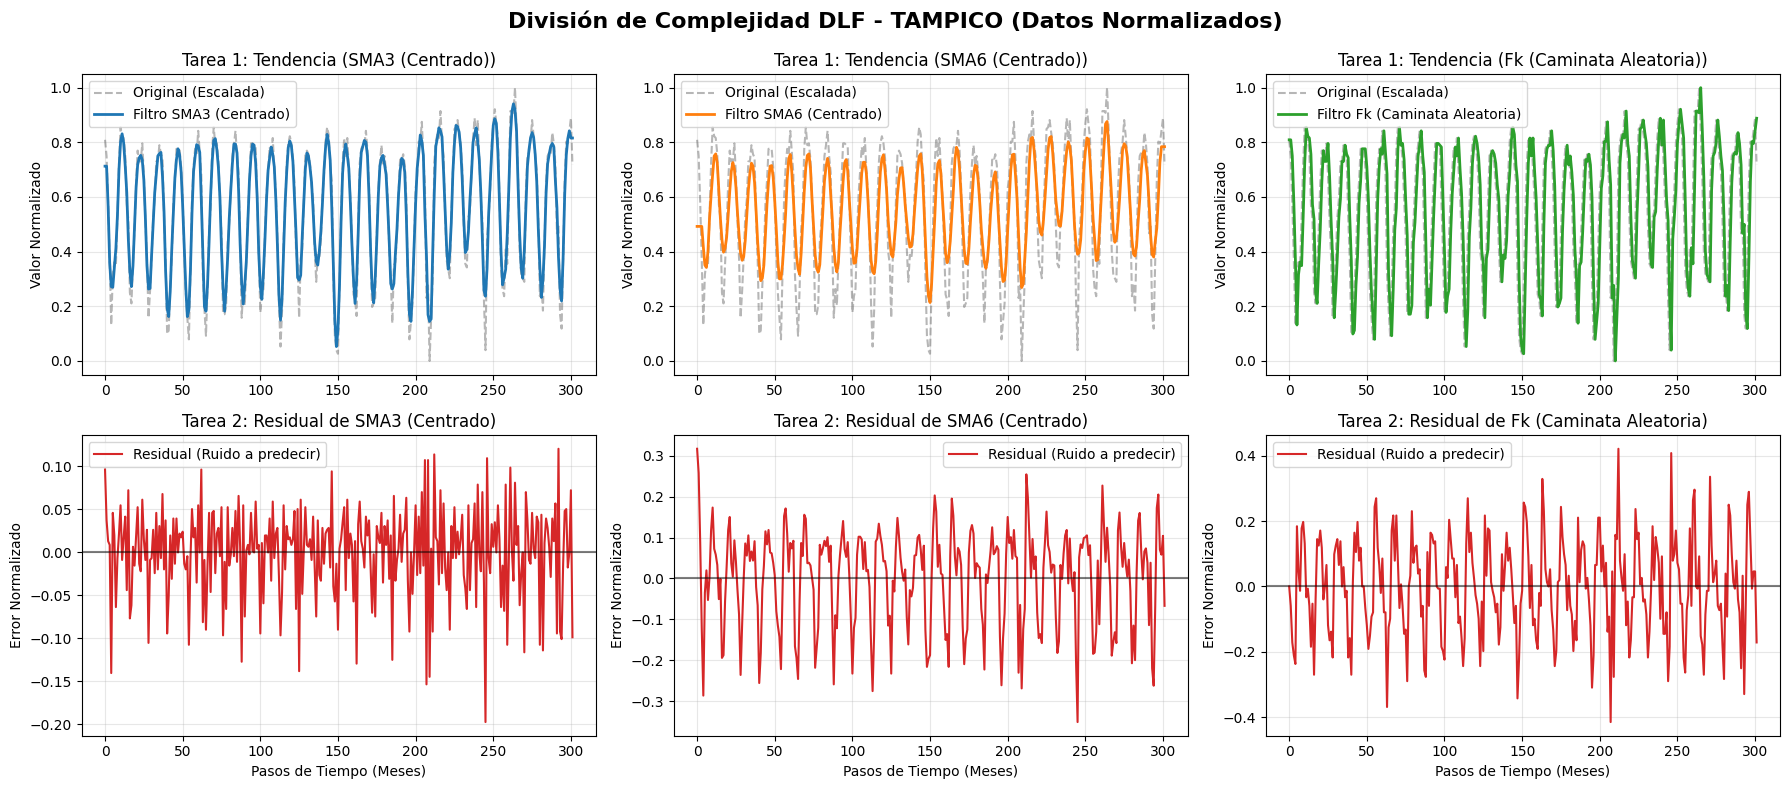

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# BLOQUE 2: DESCOMPOSICIÓN POR FILTROS (Divide and Conquer para DLF)
# =====================================================================
print("--- Aplicando Filtros de Descomposición (SMA3, SMA6, Fk) ---")
print("Nota: Medias móviles calculadas con 'center=True' para evitar desfase de fase.")
print("Nota: Se calculan sobre la serie YA NORMALIZADA (Train + Val).\n")

# Parámetros declarados explícitamente para el tutorial
window_sma3 = 3
window_sma6 = 6

for city, data in datos_dlf.items():
    # Usamos la historia ESCALADA (Train + Val) y NUNCA tocamos los datos de prueba
    series_scaled = data['scaled']['history']

    # 1. Filtro SMA3 (Media Móvil de 3 meses CENTRADA)
    # bfill() y ffill() manejan los NaNs que se generan en ambos extremos al centrar
    sma3 = pd.Series(series_scaled).rolling(window=window_sma3, center=True).mean()
    sma3 = sma3.bfill().ffill().values

    # 2. Filtro SMA6 (Media Móvil de 6 meses CENTRADA)
    sma6 = pd.Series(series_scaled).rolling(window=window_sma6, center=True).mean()
    sma6 = sma6.bfill().ffill().values

    # 3. Filtro Fk (Caminata Aleatoria / Naive: Y_t = Y_{t-1})
    # Nota: Por definición matemática, el Random Walk es hacia atrás, no se centra.
    fk = np.roll(series_scaled, shift=1)
    fk[0] = series_scaled[0]  # Rellenar el primer valor

    # Guardar los filtros (TAREA 1: Señal Suavizada en espacio normalizado)
    datos_dlf[city]['sma3'] = sma3
    datos_dlf[city]['sma6'] = sma6
    datos_dlf[city]['fk'] = fk

    # Guardar los residuales (TAREA 2: Ruido de Alta Frecuencia en espacio normalizado)
    # Fórmula: Original = Filtro + Residual
    datos_dlf[city]['res_sma3'] = series_scaled - sma3
    datos_dlf[city]['res_sma6'] = series_scaled - sma6
    datos_dlf[city]['res_fk'] = series_scaled - fk

print("[ÉXITO] Filtros y residuales normalizados calculados y almacenados para las 4 ciudades.")

# =====================================================================
# GRÁFICAS DE DIAGNÓSTICO (4 Ciudades x 3 Filtros = 12 configuraciones)
# =====================================================================

filtros_keys = ['sma3', 'sma6', 'fk']
titulos = ['SMA3 (Centrado)', 'SMA6 (Centrado)', 'Fk (Caminata Aleatoria)']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']

for city in datos_dlf.keys():
    # Obtenemos la serie de la ciudad en curso (Escalada)
    s_ciudad_scaled = datos_dlf[city]['scaled']['history']

    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    fig.suptitle(f'División de Complejidad DLF - {city} (Datos Normalizados)', fontsize=16, fontweight='bold')

    for i, (f_key, titulo, color) in enumerate(zip(filtros_keys, titulos, colores)):
        filtro_val = datos_dlf[city][f_key]
        res_val = datos_dlf[city][f'res_{f_key}']

        # Fila 0: Tarea 1 (Señal Suavizada / Tendencia)
        axes[0, i].plot(s_ciudad_scaled, label='Original (Escalada)', color='#4A4A4A', alpha=0.4, linestyle='--')
        axes[0, i].plot(filtro_val, label=f'Filtro {titulo}', color=color, linewidth=2)
        axes[0, i].set_title(f'Tarea 1: Tendencia ({titulo})', fontsize=12)
        axes[0, i].set_ylabel('Valor Normalizado') # Ajuste de etiqueta a escala 0-1
        axes[0, i].legend(loc='best')
        axes[0, i].grid(True, alpha=0.3)

        # Fila 1: Tarea 2 (Residual / Alta Frecuencia)
        axes[1, i].plot(res_val, label='Residual (Ruido a predecir)', color='#D62728', linewidth=1.5)
        axes[1, i].axhline(0, color='black', linestyle='-', alpha=0.5)
        axes[1, i].set_title(f'Tarea 2: Residual de {titulo}', fontsize=12)
        axes[1, i].set_xlabel('Pasos de Tiempo (Meses)')
        axes[1, i].set_ylabel('Error Normalizado') # Ajuste de etiqueta
        axes[1, i].legend(loc='best')
        axes[1, i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.subplots_adjust(top=0.9) # Ajuste para que el título principal no se empalme
    plt.show()

In [ ]:
### CONFIGURACIÓN DE PRONÓSTICO DE SERIES FILTRADAS

### Pronóstico de series filtradas con CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense

def build_strict_trend_cnn(input_shape):
    """
    Arquitectura CNN 1D diseñada para extraer características espaciales
    y sobreajustar (memorizar) tendencias de series de tiempo suaves (SMA3, SMA6).
    Diseñada sin Pooling y sin Dropout para no perder resolución en la tendencia.
    """
    model = Sequential([
        # Capa Conv 1: Captura el 1/4 de estacionalidad (kernel_size=3)
        # padding='same' asegura que no se encoja la ventana de 12 meses
        Conv1D(filters=64,
               kernel_size=3,
               activation='relu',
               padding='same',
               input_shape=input_shape),

        # Capa Conv 2: Captura la 1/2 de estacionalidad (kernel_size=6)
        # Mayor cantidad de filtros para extraer patrones de baja frecuencia más complejos
        Conv1D(filters=128,
               kernel_size=6,
               activation='relu',
               padding='same'),

        # Aplanamos los mapas de características temporales para pasarlos a la red densa
        Flatten(),

        # Capa Densa: Ajuste fino estricto equivalente al de la LSTM
        Dense(32, activation='relu'),

        # Salida lineal para regresión (pronóstico del mes 13)
        Dense(1)
    ])

    # Optimizador Adam con MSE (estricto penalizador de desviaciones grandes)
    model.compile(optimizer='adam', loss='mse')
    return model

### Pronóstico de series filtradas con LSTM

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

def build_strict_trend_lstm(input_shape):
    """
    Arquitectura diseñada para sobreajustar (memorizar) tendencias y señales
    de baja frecuencia (MA3, MA6), sin regularización (sin Dropout).
    """
    model = Sequential([
        # Capa 1: Extrae la dinámica base (return_sequences=True para apilar)
        LSTM(128, activation='tanh', return_sequences=True, input_shape=input_shape),

        # Capa 2: Extrae la "aceleración" o curvatura de la tendencia
        LSTM(64, activation='tanh', return_sequences=False),

        # Capa Densa: Ajuste fino estricto a la salida
        Dense(32, activation='relu'),

        # Salida lineal
        Dense(1)
    ])

    # Usamos Huber loss o MSE. MSE es más estricto con las desviaciones.
    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
### CONFIGURACIÓN DE SERIES RESIDUALES

#CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.losses import Huber # Import Huber loss

def build_residual_cnn(input_shape):
    """
    Arquitectura CNN 1D diseñada para series residuales (estocásticas).
    Incluye MaxPooling y Dropout para evitar el sobreajuste al ruido de alta frecuencia
    y extraer únicamente patrones robustos.
    """
    model = Sequential([
        # Capa Conv 1: Filtros más pequeños, buscando patrones locales rápidos
        Conv1D(filters=32,
               kernel_size=3,
               activation='relu',
               padding='same',
               input_shape=input_shape),

        # MaxPooling: A diferencia de la Tarea 1, aquí SÍ reducimos la dimensionalidad.
        # Esto otorga invarianza traslacional (no importa exactamente cuándo ocurrió el pico de ruido)
        MaxPooling1D(pool_size=2),
        Dropout(0.2), # Apaga el 20% de las neuronas para forzar la generalización

        # Capa Conv 2: Extracción de características de nivel superior del ruido
        Conv1D(filters=64,
               kernel_size=3,
               activation='relu',
               padding='same'),

        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Flatten(),

        # Capa Densa regularizada
        Dense(32, activation='relu'),
        Dropout(0.1),

        # Salida lineal
        Dense(1)
    ])

    # Usamos Huber Loss en lugar de MSE.
    # Huber penaliza menos los outliers severos típicos en las series residuales.
    model.compile(optimizer='adam', loss=Huber()) # Use Huber() instead of 'huber_loss'
    return model

#LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def build_residual_lstm(input_shape):
    """
    Arquitectura LSTM para series residuales.
    Utiliza menos unidades (para no memorizar) y fuerte regularización por Dropout.
    """
    model = Sequential([
        # Capa 1: Menos unidades que en Tarea 1 (64 en lugar de 128)
        # para restringir la capacidad de memorización de la red.
        LSTM(64, activation='tanh', return_sequences=True, input_shape=input_shape),
        Dropout(0.2), # Regularización indispensable para señales ruidosas

        # Capa 2: Compresión del estado oculto
        LSTM(32, activation='tanh', return_sequences=False),
        Dropout(0.2),

        # Capa Densa para ajuste final
        Dense(16, activation='relu'),

        # Salida lineal
        Dense(1)
    ])

    # Nuevamente, Huber Loss protege los gradientes de ser destruidos por un valor residual atípico
    model.compile(optimizer='adam', loss=Huber()) # Use Huber() instead of 'huber_loss'
    return model

In [ ]:
### EL QUE SI GUARDA

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# =====================================================================
# BLOQUE 3 Y 4: ENTRENAMIENTO, RECONSTRUCCIÓN Y EVALUACIÓN RMSE
# =====================================================================
print("--- Iniciando Entrenamiento Profundo y Ensamblaje FMFRA-DLF ---")
print("Nota: Evaluando pares homogéneos (CNN+CNN vs LSTM+LSTM) por cada filtro.\n")

epochs_train = 100
batch_size_train = 12
filtros = ['sma3', 'sma6', 'fk']

# Guardaremos los resultados finales de validación aquí
resultados_dlf = {}

for city in datos_dlf.keys():
    print(f"==================================================")
    print(f"Procesando pronósticos para la ciudad: {city}")
    print(f"==================================================")

    resultados_dlf[city] = {}
    scaler = datos_dlf[city]['scaler']

    # CORRECCIÓN: Extraer la validación directamente desde 'raw_full'
    y_true_celsius = datos_dlf[city]['raw_full'][n_train:]

    for filtro in filtros:
        print(f"  -> Entrenando modelos para filtro {filtro.upper()} y su residual...")

        # 1. Extraer series normalizadas de Base y Residual
        base_s = datos_dlf[city][filtro]
        resi_s = datos_dlf[city][f'res_{filtro}']

        # 2. Generar particiones Train / Val (extendida) para ambas
        base_train = base_s[:n_train]
        base_val   = base_s[n_train - window_size : n_train + len(y_true_celsius)]

        resi_train = resi_s[:n_train]
        resi_val   = resi_s[n_train - window_size : n_train + len(y_true_celsius)]

        # 3. Creación de Datasets Supervisados (X, y)
        X_base_tr, y_base_tr = crear_dataset_supervisado(base_train, window_size)
        X_base_v, _          = crear_dataset_supervisado(base_val, window_size)

        X_resi_tr, y_resi_tr = crear_dataset_supervisado(resi_train, window_size)
        X_resi_v, _          = crear_dataset_supervisado(resi_val, window_size)

        # 4. Reshape a 3D Tensor para Keras [samples, timesteps, features]
        X_base_tr_3d = X_base_tr.reshape(-1, window_size, 1)
        X_base_v_3d  = X_base_v.reshape(-1, window_size, 1)

        X_resi_tr_3d = X_resi_tr.reshape(-1, window_size, 1)
        X_resi_v_3d  = X_resi_v.reshape(-1, window_size, 1)

        # =========================================================
        # 5. INSTANCIACIÓN Y ENTRENAMIENTO (Pares Arquitectónicos)
        # =========================================================

        # --- ENSAMBLE A: CNN-Trend + CNN-Resi ---
        cnn_trend = build_strict_trend_cnn((window_size, 1))
        cnn_resi  = build_residual_cnn((window_size, 1))

        cnn_trend.fit(X_base_tr_3d, y_base_tr, epochs=epochs_train, batch_size=batch_size_train, verbose=0)
        cnn_resi.fit(X_resi_tr_3d, y_resi_tr, epochs=epochs_train, batch_size=batch_size_train, verbose=0)

        pred_cnn_base = cnn_trend.predict(X_base_v_3d, verbose=0)
        pred_cnn_resi = cnn_resi.predict(X_resi_v_3d, verbose=0)

        # Reconstrucción CNN (Suma en espacio normalizado)
        pred_cnn_total_scaled = pred_cnn_base + pred_cnn_resi
        pred_cnn_celsius = scaler.inverse_transform(pred_cnn_total_scaled).flatten()

        # --- ENSAMBLE B: LSTM-Trend + LSTM-Resi ---
        lstm_trend = build_strict_trend_lstm((window_size, 1))
        lstm_resi  = build_residual_lstm((window_size, 1))

        lstm_trend.fit(X_base_tr_3d, y_base_tr, epochs=epochs_train, batch_size=batch_size_train, verbose=0)
        lstm_resi.fit(X_resi_tr_3d, y_resi_tr, epochs=epochs_train, batch_size=batch_size_train, verbose=0)

        pred_lstm_base = lstm_trend.predict(X_base_v_3d, verbose=0)
        pred_lstm_resi = lstm_resi.predict(X_resi_v_3d, verbose=0)

        # Reconstrucción LSTM (Suma en espacio normalizado)
        pred_lstm_total_scaled = pred_lstm_base + pred_lstm_resi
        pred_lstm_celsius = scaler.inverse_transform(pred_lstm_total_scaled).flatten()

        # =========================================================
        # 6. EVALUACIÓN Y SELECCIÓN DEL MEJOR MODELO
        # =========================================================
        rmse_cnn  = np.sqrt(mean_squared_error(y_true_celsius, pred_cnn_celsius))
        rmse_lstm = np.sqrt(mean_squared_error(y_true_celsius, pred_lstm_celsius))

        if rmse_cnn < rmse_lstm:
            mejor_modelo = 'CNN (Trend+Resi)'
            mejor_pred = pred_cnn_celsius
            mejor_rmse = rmse_cnn
        else:
            mejor_modelo = 'LSTM (Trend+Resi)'
            mejor_pred = pred_lstm_celsius
            mejor_rmse = rmse_lstm

        resultados_dlf[city][filtro] = {
            'modelo': mejor_modelo,
            'prediccion': mejor_pred,
            'rmse': mejor_rmse
        }
        print(f"     [OK] Ganador: {mejor_modelo} | RMSE: {mejor_rmse:.4f} °C")

print("\n[ÉXITO] Modelos entrenados y evaluados. Preparando visualización de Validación...")

# =====================================================================
# GRÁFICAS FINALES DE VALIDACIÓN (Seleccionando el de Menor RMSE)
# =====================================================================

titulos_filtros = {'sma3': 'Filtro SMA3', 'sma6': 'Filtro SMA6', 'fk': 'Filtro Fk (Random Walk)'}

for city in datos_dlf.keys():
    # CORRECCIÓN: Extraer la validación directamente desde 'raw_full'
    y_true_celsius = datos_dlf[city]['raw_full'][n_train:]

    # 1 figura por ciudad con 3 subplots (1 por cada filtro)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Pronósticos de Validación FMFRA-DLF - {city}', fontsize=16, fontweight='bold')

    for i, filtro in enumerate(filtros):
        # Extraer los resultados del ganador
        mejor_modelo = resultados_dlf[city][filtro]['modelo']
        mejor_pred = resultados_dlf[city][filtro]['prediccion']
        mejor_rmse = resultados_dlf[city][filtro]['rmse']

        # Eje temporal para la validación (meses)
        tiempo_val = np.arange(len(y_true_celsius))

        # Gráfica
        axes[i].plot(tiempo_val, y_true_celsius, label='Real (°C)', color='#2C3E50', linewidth=2, linestyle='--')
        axes[i].plot(tiempo_val, mejor_pred, label=f'Pronóstico {mejor_modelo}', color='#E74C3C', linewidth=2)

        axes[i].set_title(f'{titulos_filtros[filtro]}\nRMSE: {mejor_rmse:.3f} °C', fontsize=12)
        axes[i].set_xlabel('Meses de Validación')
        axes[i].set_ylabel('Temperatura (°C)')
        axes[i].legend(loc='best')
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85) # Espacio para el título general
    plt.show()

--- Iniciando Entrenamiento Profundo y Ensamblaje FMFRA-DLF ---
Nota: Evaluando pares homogéneos (CNN+CNN vs LSTM+LSTM) por cada filtro.

Procesando pronósticos para la ciudad: HOUSTON
  -> Entrenando modelos para filtro SMA3 y su residual...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     [OK] Ganador: CNN (Trend+Resi) | RMSE: 0.8051 °C
  -> Entrenando modelos para filtro SMA6 y su residual...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


KeyboardInterrupt: 

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Crear directorio para guardar los modelos físicos y no saturar tu Colab
os.makedirs('modelos_FMFRA', exist_ok=True)

# =====================================================================
# BLOQUE 4: VALIDACIÓN CRUZADA DESLIZANTE (WALK-FORWARD VALIDATION)
# =====================================================================
print("--- Iniciando Validación Cruzada Rodante (Walk-Forward) ---")
print("Evaluando ventanas estrictas de 34 pasos rodantes sobre la Validación.\n")

epochs_train = 100
batch_size_train = 16
filtros = ['sma3', 'sma6', 'fk']

# Tamaño de ventana que te interesa evaluar (el mismo del test futuro)
h_pronostico = 34

resultados_dlf = {}

for city in datos_dlf.keys():
    print(f"==================================================")
    print(f"Procesando ciudad: {city}")

    resultados_dlf[city] = {}
    scaler = datos_dlf[city]['scaler']

    for filtro in filtros:
        print(f"  -> Entrenando y evaluando filtro {filtro.upper()}...")

        # 1. Extracción de datos
        base_s = datos_dlf[city][filtro]
        resi_s = datos_dlf[city][f'res_{filtro}']

        # Entrenamiento
        base_train = base_s[:n_train]
        resi_train = resi_s[:n_train]

        # Historia completa para tomar las semillas rodantes
        base_hist = base_s[:n_train + n_val]
        resi_hist = resi_s[:n_train + n_val]

        # Datasets supervisados (Solo Train)
        X_base_tr, y_base_tr = crear_dataset_supervisado(base_train, window_size)
        X_resi_tr, y_resi_tr = crear_dataset_supervisado(resi_train, window_size)

        X_base_tr_3d = X_base_tr.reshape(-1, window_size, 1)
        X_resi_tr_3d = X_resi_tr.reshape(-1, window_size, 1)

        # 2. Entrenamiento de Redes
        cnn_trend = build_strict_trend_cnn((window_size, 1))
        cnn_resi  = build_residual_cnn((window_size, 1))
        cnn_trend.fit(X_base_tr_3d, y_base_tr, epochs=epochs_train, batch_size=batch_size_train, verbose=0)
        cnn_resi.fit(X_resi_tr_3d, y_resi_tr, epochs=epochs_train, batch_size=batch_size_train, verbose=0)

        lstm_trend = build_strict_trend_lstm((window_size, 1))
        lstm_resi  = build_residual_lstm((window_size, 1))
        lstm_trend.fit(X_base_tr_3d, y_base_tr, epochs=epochs_train, batch_size=batch_size_train, verbose=0)
        lstm_resi.fit(X_resi_tr_3d, y_resi_tr, epochs=epochs_train, batch_size=batch_size_train, verbose=0)

        # =========================================================
        # 3. LA MAGIA: EVALUACIÓN WALK-FORWARD (VENTANAS DE 34)
        # =========================================================

        # Cuántas ventanas de 34 caben en tus 68 datos de validación: (68 - 34 + 1) = 35 ventanas
        num_ventanas = n_val - h_pronostico + 1

        rmse_ventanas_cnn = []
        rmse_ventanas_lstm = []

        # Bucle que desplaza el origen 1 paso a la vez
        for i in range(num_ventanas):
            # Índice donde "empieza" el pronóstico de esta iteración
            start_idx = n_train + i

            # Semilla aislada de 12 meses antes del inicio
            seq_b_cnn = base_hist[start_idx - window_size : start_idx]
            seq_r_cnn = resi_hist[start_idx - window_size : start_idx]

            seq_b_lstm = base_hist[start_idx - window_size : start_idx]
            seq_r_lstm = resi_hist[start_idx - window_size : start_idx]

            preds_cnn_scaled = []
            preds_lstm_scaled = []

            # Bucle recursivo interno: pronosticar EXACTAMENTE 34 pasos
            for _ in range(h_pronostico):
                # CNN
                p_b_cnn = cnn_trend.predict(seq_b_cnn.reshape(1, window_size, 1), verbose=0)[0][0]
                p_r_cnn = cnn_resi.predict(seq_r_cnn.reshape(1, window_size, 1), verbose=0)[0][0]
                preds_cnn_scaled.append(p_b_cnn + p_r_cnn)
                seq_b_cnn = np.append(seq_b_cnn[1:], p_b_cnn)
                seq_r_cnn = np.append(seq_r_cnn[1:], p_r_cnn)

                # LSTM
                p_b_lstm = lstm_trend.predict(seq_b_lstm.reshape(1, window_size, 1), verbose=0)[0][0]
                p_r_lstm = lstm_resi.predict(seq_r_lstm.reshape(1, window_size, 1), verbose=0)[0][0]
                preds_lstm_scaled.append(p_b_lstm + p_r_lstm)
                seq_b_lstm = np.append(seq_b_lstm[1:], p_b_lstm)
                seq_r_lstm = np.append(seq_r_lstm[1:], p_r_lstm)

            # Revertir escala de la ventana
            pred_cnn_celsius = scaler.inverse_transform(np.array(preds_cnn_scaled).reshape(-1, 1)).flatten()
            pred_lstm_celsius = scaler.inverse_transform(np.array(preds_lstm_scaled).reshape(-1, 1)).flatten()

            # Extraer la verdad de esos 34 pasos exactos
            y_true_ventana = datos_dlf[city]['raw_full'][start_idx : start_idx + h_pronostico]

            # Calcular y guardar el RMSE de esta ventana de 34
            rmse_ventanas_cnn.append(np.sqrt(mean_squared_error(y_true_ventana, pred_cnn_celsius)))
            rmse_ventanas_lstm.append(np.sqrt(mean_squared_error(y_true_ventana, pred_lstm_celsius)))

        # 4. RMSE Promedio de las 35 ventanas
        promedio_rmse_cnn = np.mean(rmse_ventanas_cnn)
        promedio_rmse_lstm = np.mean(rmse_ventanas_lstm)

        # Guardamos el mejor basado en la solidez a lo largo de 35 pruebas
        if promedio_rmse_cnn < promedio_rmse_lstm:
            resultados_dlf[city][filtro] = {
                'modelo': 'CNN',
                'rmse': promedio_rmse_cnn,
                'ultima_pred_grafica': pred_cnn_celsius,
                'ultima_verdad_grafica': y_true_ventana
            }
            # Guardado físico de los pesos de CNN ganadora
            cnn_trend.save(f'modelos_FMFRA/{city}_{filtro}_trend_CNN.keras')
            cnn_resi.save(f'modelos_FMFRA/{city}_{filtro}_resi_CNN.keras')
        else:
            resultados_dlf[city][filtro] = {
                'modelo': 'LSTM',
                'rmse': promedio_rmse_lstm,
                'ultima_pred_grafica': pred_lstm_celsius,
                'ultima_verdad_grafica': y_true_ventana
            }
            # Guardado físico de los pesos de LSTM ganadora
            lstm_trend.save(f'modelos_FMFRA/{city}_{filtro}_trend_LSTM.keras')
            lstm_resi.save(f'modelos_FMFRA/{city}_{filtro}_resi_LSTM.keras')

        print(f"     [OK] Ganador (35 escenarios): {resultados_dlf[city][filtro]['modelo']} | RMSE Promedio: {resultados_dlf[city][filtro]['rmse']:.4f} °C")

print("\n[ÉXITO] Modelos evaluados y guardados en disco.")

# =====================================================================
# AGREGADO: EXPORTACIÓN DE RESULTADOS A CSV
# =====================================================================
registros = []

for city in resultados_dlf.keys():
    for filtro in filtros:
        datos_filtro = resultados_dlf[city][filtro]
        registros.append({
            'Ciudad': city,
            'Filtro': filtro.upper(),
            'Arquitectura_Ganadora': datos_filtro['modelo'],
            'RMSE_Validacion_WalkForward': round(datos_filtro['rmse'], 4)
        })

# Convertir a DataFrame y guardar
df_resultados_val = pd.DataFrame(registros)
df_resultados_val.to_csv('Resultados_Validacion_WalkForward.csv', index=False)

print("--------------------------------------------------")
print("Archivo 'Resultados_Validacion_WalkForward.csv' generado correctamente.")
print("Los modelos pre-entrenados están asegurados en la carpeta '/modelos_FMFRA/'.")

--- Iniciando Validación Cruzada Rodante (Walk-Forward) ---
Evaluando ventanas estrictas de 34 pasos rodantes sobre la Validación.

Procesando ciudad: HOUSTON
  -> Entrenando y evaluando filtro SMA3...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


     [OK] Ganador (35 escenarios): LSTM | RMSE Promedio: 1.8055 °C
  -> Entrenando y evaluando filtro SMA6...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     [OK] Ganador (35 escenarios): LSTM | RMSE Promedio: 1.6685 °C
  -> Entrenando y evaluando filtro FK...


...

     [OK] Ganador (35 escenarios): LSTM | RMSE Promedio: 1.9466 °C
  -> Entrenando y evaluando filtro SMA6...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     [OK] Ganador (35 escenarios): CNN | RMSE Promedio: 1.2355 °C
  -> Entrenando y evaluando filtro FK...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     [OK] Ganador (35 escenarios): CNN | RMSE Promedio: 1.8253 °C

[ÉXITO] Modelos evaluados y guardados en disco.
--------------------------------------------------
Archivo 'Resultados_Validacion_WalkForward.csv' generado correctamente.
Los modelos pre-entrenados están asegurados en la carpeta '/modelos_FMFRA/'.


In [7]:
from google.colab import files

# Descargar el CSV a tu máquina local
files.download('Resultados_Validacion_WalkForward.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import numpy as np
import pandas as pd
from google.colab import files

# =====================================================================
# EXPORTACIÓN DE PRONÓSTICOS DE PRUEBA (PARA EVALUACIÓN EXTERNA)
# =====================================================================
print("--- Generando Pronósticos Ciegos (34 pasos) para Evaluación Externa ---")

ciudades = list(datos_dlf.keys())
ventanas_pronostico = 34
filtros_evaluados = ['sma3', 'sma6', 'fk']
resultados_exportacion = []

for city in ciudades:
    # 1. Recuperar al GANADOR ABSOLUTO de la Validación
    mejor_rmse_val = float('inf')
    mejor_filtro = ''
    mejor_modelo_nombre = ''

    for f in filtros_evaluados:
        rmse_val_actual = resultados_dlf[city][f]['rmse']
        if rmse_val_actual < mejor_rmse_val:
            mejor_rmse_val = rmse_val_actual
            mejor_filtro = f
            mejor_modelo_nombre = resultados_dlf[city][f]['modelo']

    print(f"[{city}] Generando pronóstico con {mejor_modelo_nombre} ({mejor_filtro.upper()})")

    # 2. Extraer la "Semilla" de arranque (los últimos 12 meses de Validación)
    inicio_test = n_train + n_val
    seq_base = datos_dlf[city][mejor_filtro][inicio_test - window_size : inicio_test]
    seq_resi = datos_dlf[city][f'res_{mejor_filtro}'][inicio_test - window_size : inicio_test]

    scaler = datos_dlf[city]['scaler']
    predicciones_celsius = []

    # 3. Inferencia Recursiva (34 Pasos)
    for _ in range(ventanas_pronostico):
        in_base_3d = seq_base.reshape(1, window_size, 1)
        in_resi_3d = seq_resi.reshape(1, window_size, 1)

        if 'CNN' in mejor_modelo_nombre:
            p_base = cnn_trend.predict(in_base_3d, verbose=0)[0][0]
            p_resi = cnn_resi.predict(in_resi_3d, verbose=0)[0][0]
        else:
            p_base = lstm_trend.predict(in_base_3d, verbose=0)[0][0]
            p_resi = lstm_resi.predict(in_resi_3d, verbose=0)[0][0]

        p_total_scaled = p_base + p_resi
        p_celsius = scaler.inverse_transform([[p_total_scaled]])[0][0]
        predicciones_celsius.append(p_celsius)

        seq_base = np.append(seq_base[1:], p_base)
        seq_resi = np.append(seq_resi[1:], p_resi)

    # 4. Guardar los 34 valores en una estructura para el CSV
    for paso, valor in enumerate(predicciones_celsius):
        resultados_exportacion.append({
            'Ciudad': city,
            'Paso': paso + 1,
            'Pronostico_FMFRA': valor
        })

# 5. Crear el DataFrame y descargarlo
df_export = pd.DataFrame(resultados_exportacion)
df_export.to_csv('Pronosticos_FMFRA_Prueba.csv', index=False)

print("\n[ÉXITO] Pronósticos generados y listos para descargar.")
files.download('Pronosticos_FMFRA_Prueba.csv')

--- Generando Pronósticos Ciegos (34 pasos) para Evaluación Externa ---
[HOUSTON] Generando pronóstico con LSTM (FK)
[MATAMOROS] Generando pronóstico con LSTM (SMA3)
[MIAMI] Generando pronóstico con LSTM (SMA6)
[TAMPICO] Generando pronóstico con CNN (SMA6)

[ÉXITO] Pronósticos generados y listos para descargar.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>